# Final Evaluation & Backtesting

*Companion notebook — the scripts in `src/` are the source of truth; this notebook loads and displays their outputs.*

In [1]:
import os, sys, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..')); os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from config import *


## 1. Walk-forward validation table (model selection)

In [2]:
cv = pd.read_csv(os.path.join(RESULTS_DIR, 'cv_results.csv'))
cv.sort_values(['asset','RMSE_ret_mean']).round(5)

,asset,model,n_folds,RMSE_ret_mean,RMSE_ret_std,MAE_ret_mean,MAE_ret_std,R2_ret_mean,R2_ret_std,DirAcc_pct_mean,DirAcc_pct_std,RMSE_usd_mean,RMSE_usd_std
0,Bitcoin,Naive-Zero,4,0.02504,0.00246,0.01778,0.00208,-0.00662,0.00481,0.00000,0.00000,2068.38741,200.01830
2,Bitcoin,ARIMA,4,0.02519,0.00269,0.01806,0.00226,-0.01694,0.02090,49.42857,3.34420,2086.08832,197.41133
6,Bitcoin,CatBoost,4,0.02521,0.00260,0.01802,0.00223,-0.01897,0.01685,49.85714,1.63507,2084.70375,196.30135
5,Bitcoin,LightGBM,4,0.02521,0.00262,0.01802,0.00224,-0.01938,0.01733,49.85714,1.63507,2085.72352,194.31676
1,Bitcoin,Naive-Mean,4,0.02522,0.00259,0.01807,0.00219,-0.02004,0.01710,49.85714,1.63507,2087.91150,196.95334
3,Bitcoin,Ridge,4,0.02525,0.00265,0.01807,0.00224,-0.02221,0.01998,49.85714,1.63507,2089.05816,196.26314
4,Bitcoin,RandomForest,4,0.02555,0.00266,0.01822,0.00215,-0.04698,0.03185,47.71429,1.69031,2116.97574,212.29837
8,Bitcoin,LSTM,4,0.02627,0.00363,0.01922,0.00309,-0.10292,0.10641,47.71429,2.69542,2156.47938,132.87298
7,Bitcoin,GRU,4,0.02664,0.00310,0.01940,0.00252,-0.13546,0.04873,50.57143,2.19461,2180.05308,198.07879
15,Gold,CatBoost,4,0.01312,0.00406,0.00931,0.00213,0.00902,0.01772,58.83621,4.77554,46.18204,27.16940


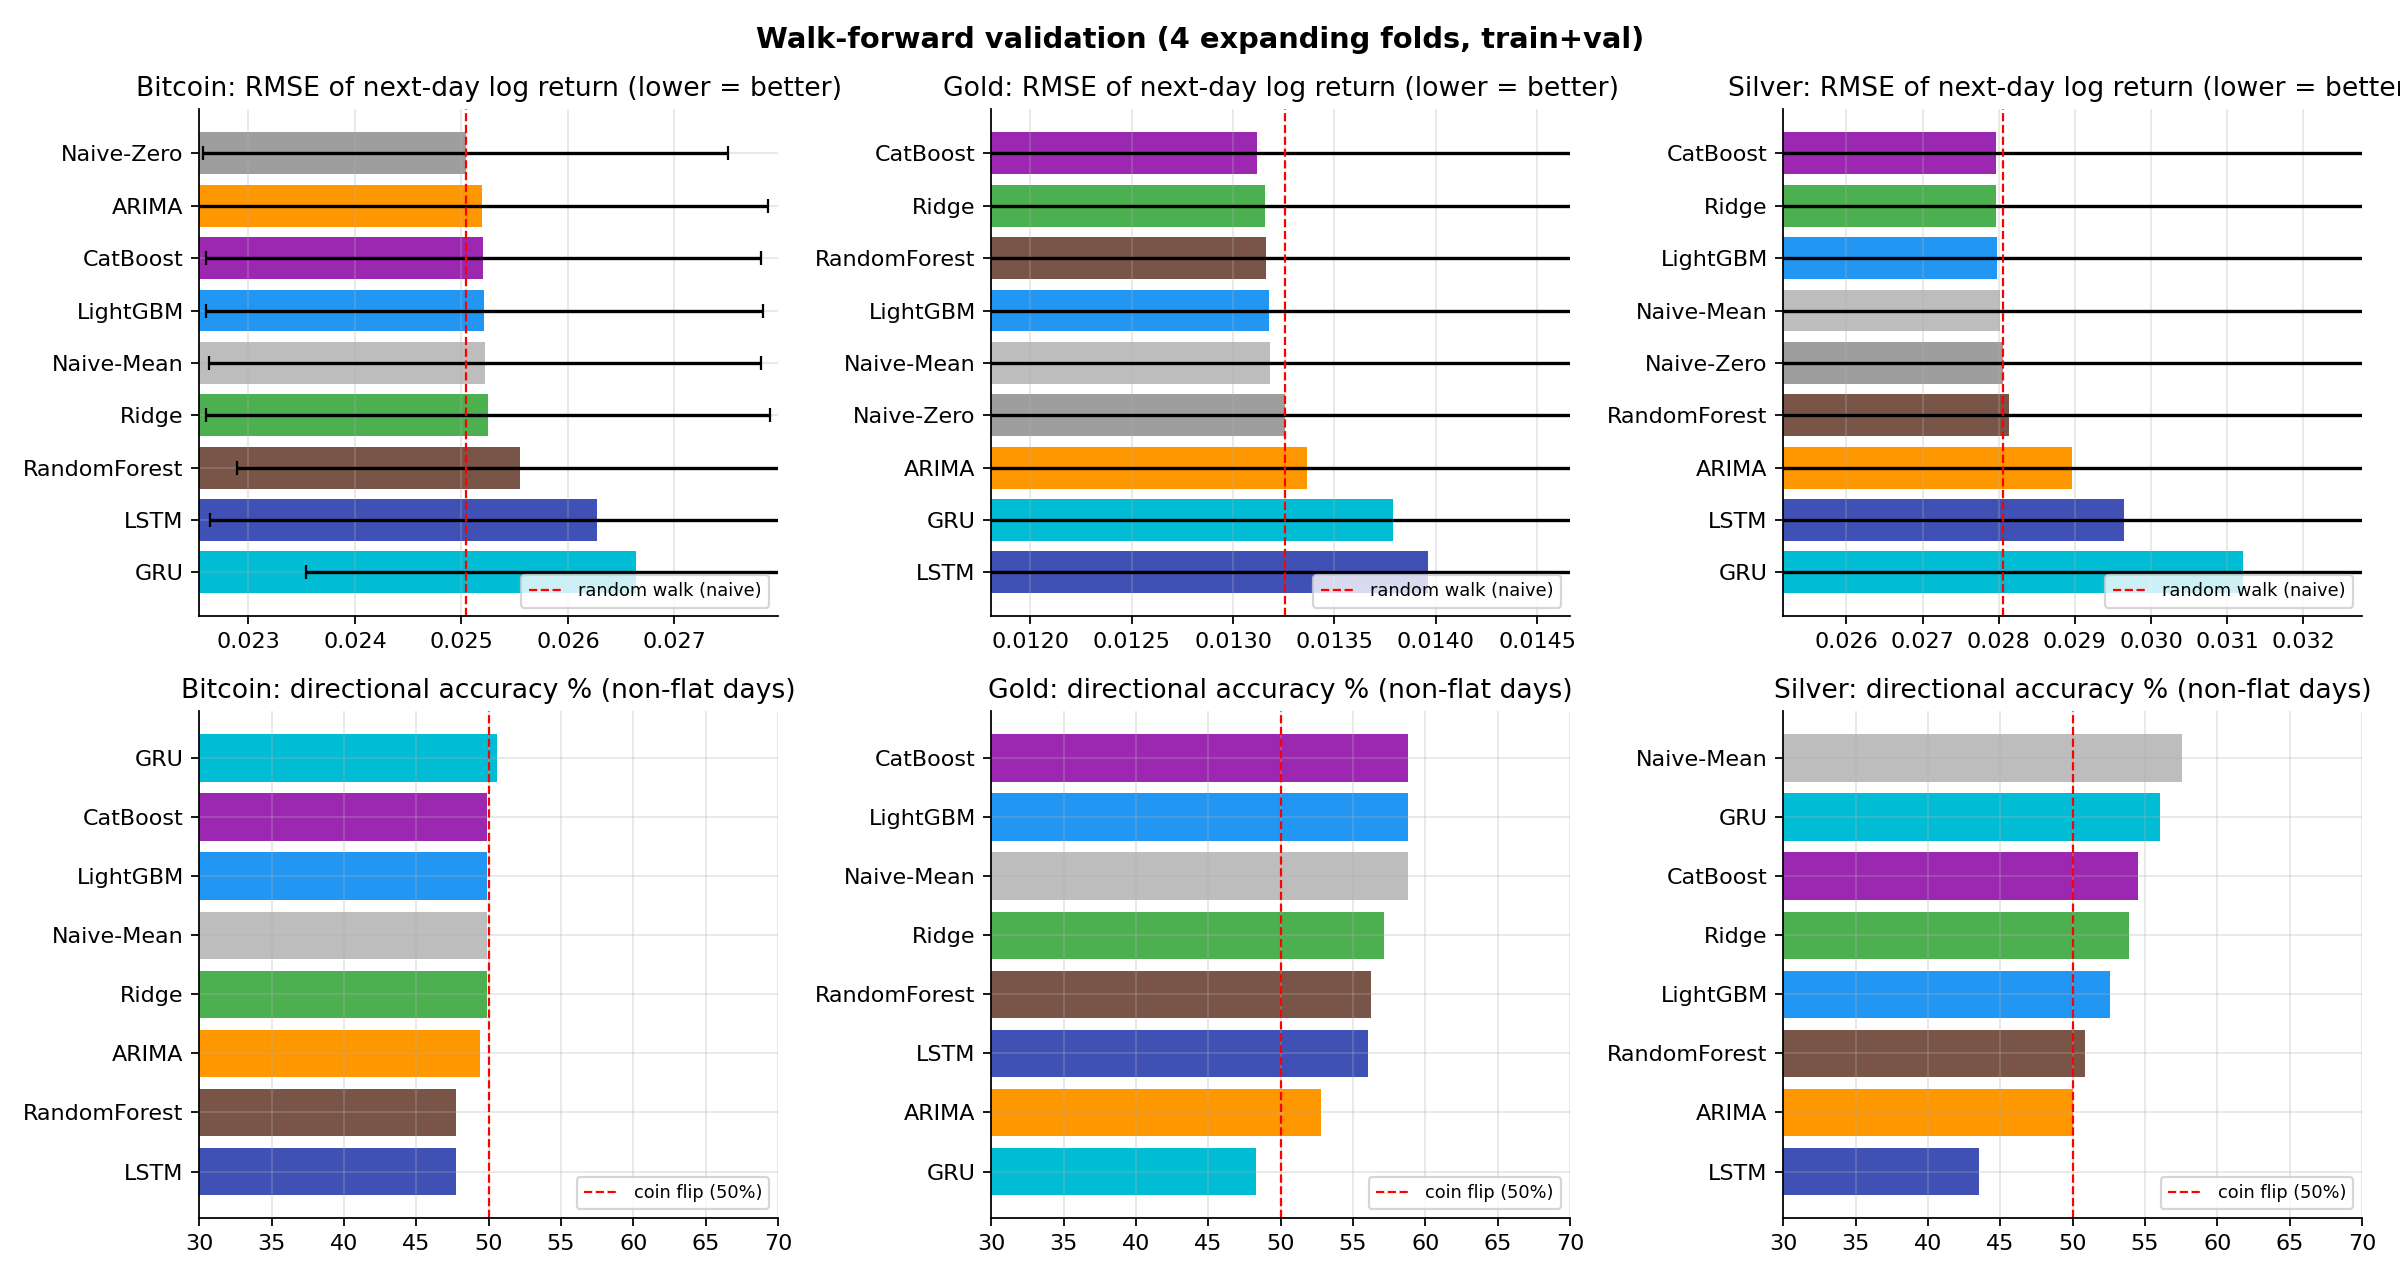

In [3]:
display(Image(os.path.join(FIGURES_DIR, 'model_comparison_cv.png')))

## 2. Untouched test set — evaluated once

In [4]:
te = pd.read_csv(os.path.join(RESULTS_DIR, 'final_test_results.csv'))
te[['asset','model','MAE_usd','RMSE_usd','MAPE_usd','RMSE_ret','R2_ret','DirAcc_pct','DirAcc_pvalue','DM_pvalue','strategy_return_pct','buy_hold_return_pct']].sort_values(['asset','RMSE_ret']).round(4)

,asset,model,MAE_usd,RMSE_usd,MAPE_usd,RMSE_ret,R2_ret,DirAcc_pct,DirAcc_pvalue,DM_pvalue,strategy_return_pct,buy_hold_return_pct
4,Bitcoin,RandomForest,1094.6894,1414.9506,1.5867,0.0206,0.0072,52.7950,0.2643,0.5992,3.0563,-6.0683
0,Bitcoin,Naive-Zero,1093.4788,1421.1200,1.5824,0.0206,-0.0004,0.0000,1.0000,NaN,0.0000,-6.0683
9,Bitcoin,Stacked,1093.8573,1421.3782,1.5832,0.0206,-0.0006,47.8261,0.7357,0.7828,-6.1621,-6.0683
3,Bitcoin,Ridge,1098.7092,1423.2694,1.5908,0.0207,-0.0028,44.7205,0.9221,0.7384,-16.6305,-6.0683
5,Bitcoin,LightGBM,1096.7425,1423.6984,1.5890,0.0207,-0.0030,47.8261,0.7357,0.7548,-6.1621,-6.0683
6,Bitcoin,CatBoost,1096.7027,1424.8068,1.5885,0.0207,-0.0046,47.8261,0.7357,0.5653,-6.1621,-6.0683
1,Bitcoin,Naive-Mean,1097.4430,1425.1287,1.5898,0.0207,-0.0050,47.8261,0.7357,0.5708,-6.1621,-6.0683
2,Bitcoin,ARIMA,1102.3290,1434.9347,1.5977,0.0208,-0.0197,51.5528,0.3763,0.2972,-7.8310,-6.0683
8,Bitcoin,LSTM,1177.2232,1515.6953,1.6997,0.0222,-0.1527,52.1739,0.3182,0.0290,0.0000,-6.0683
7,Bitcoin,GRU,1210.1795,1534.1675,1.7484,0.0224,-0.1816,52.1739,0.3182,0.0102,0.0000,-6.0683


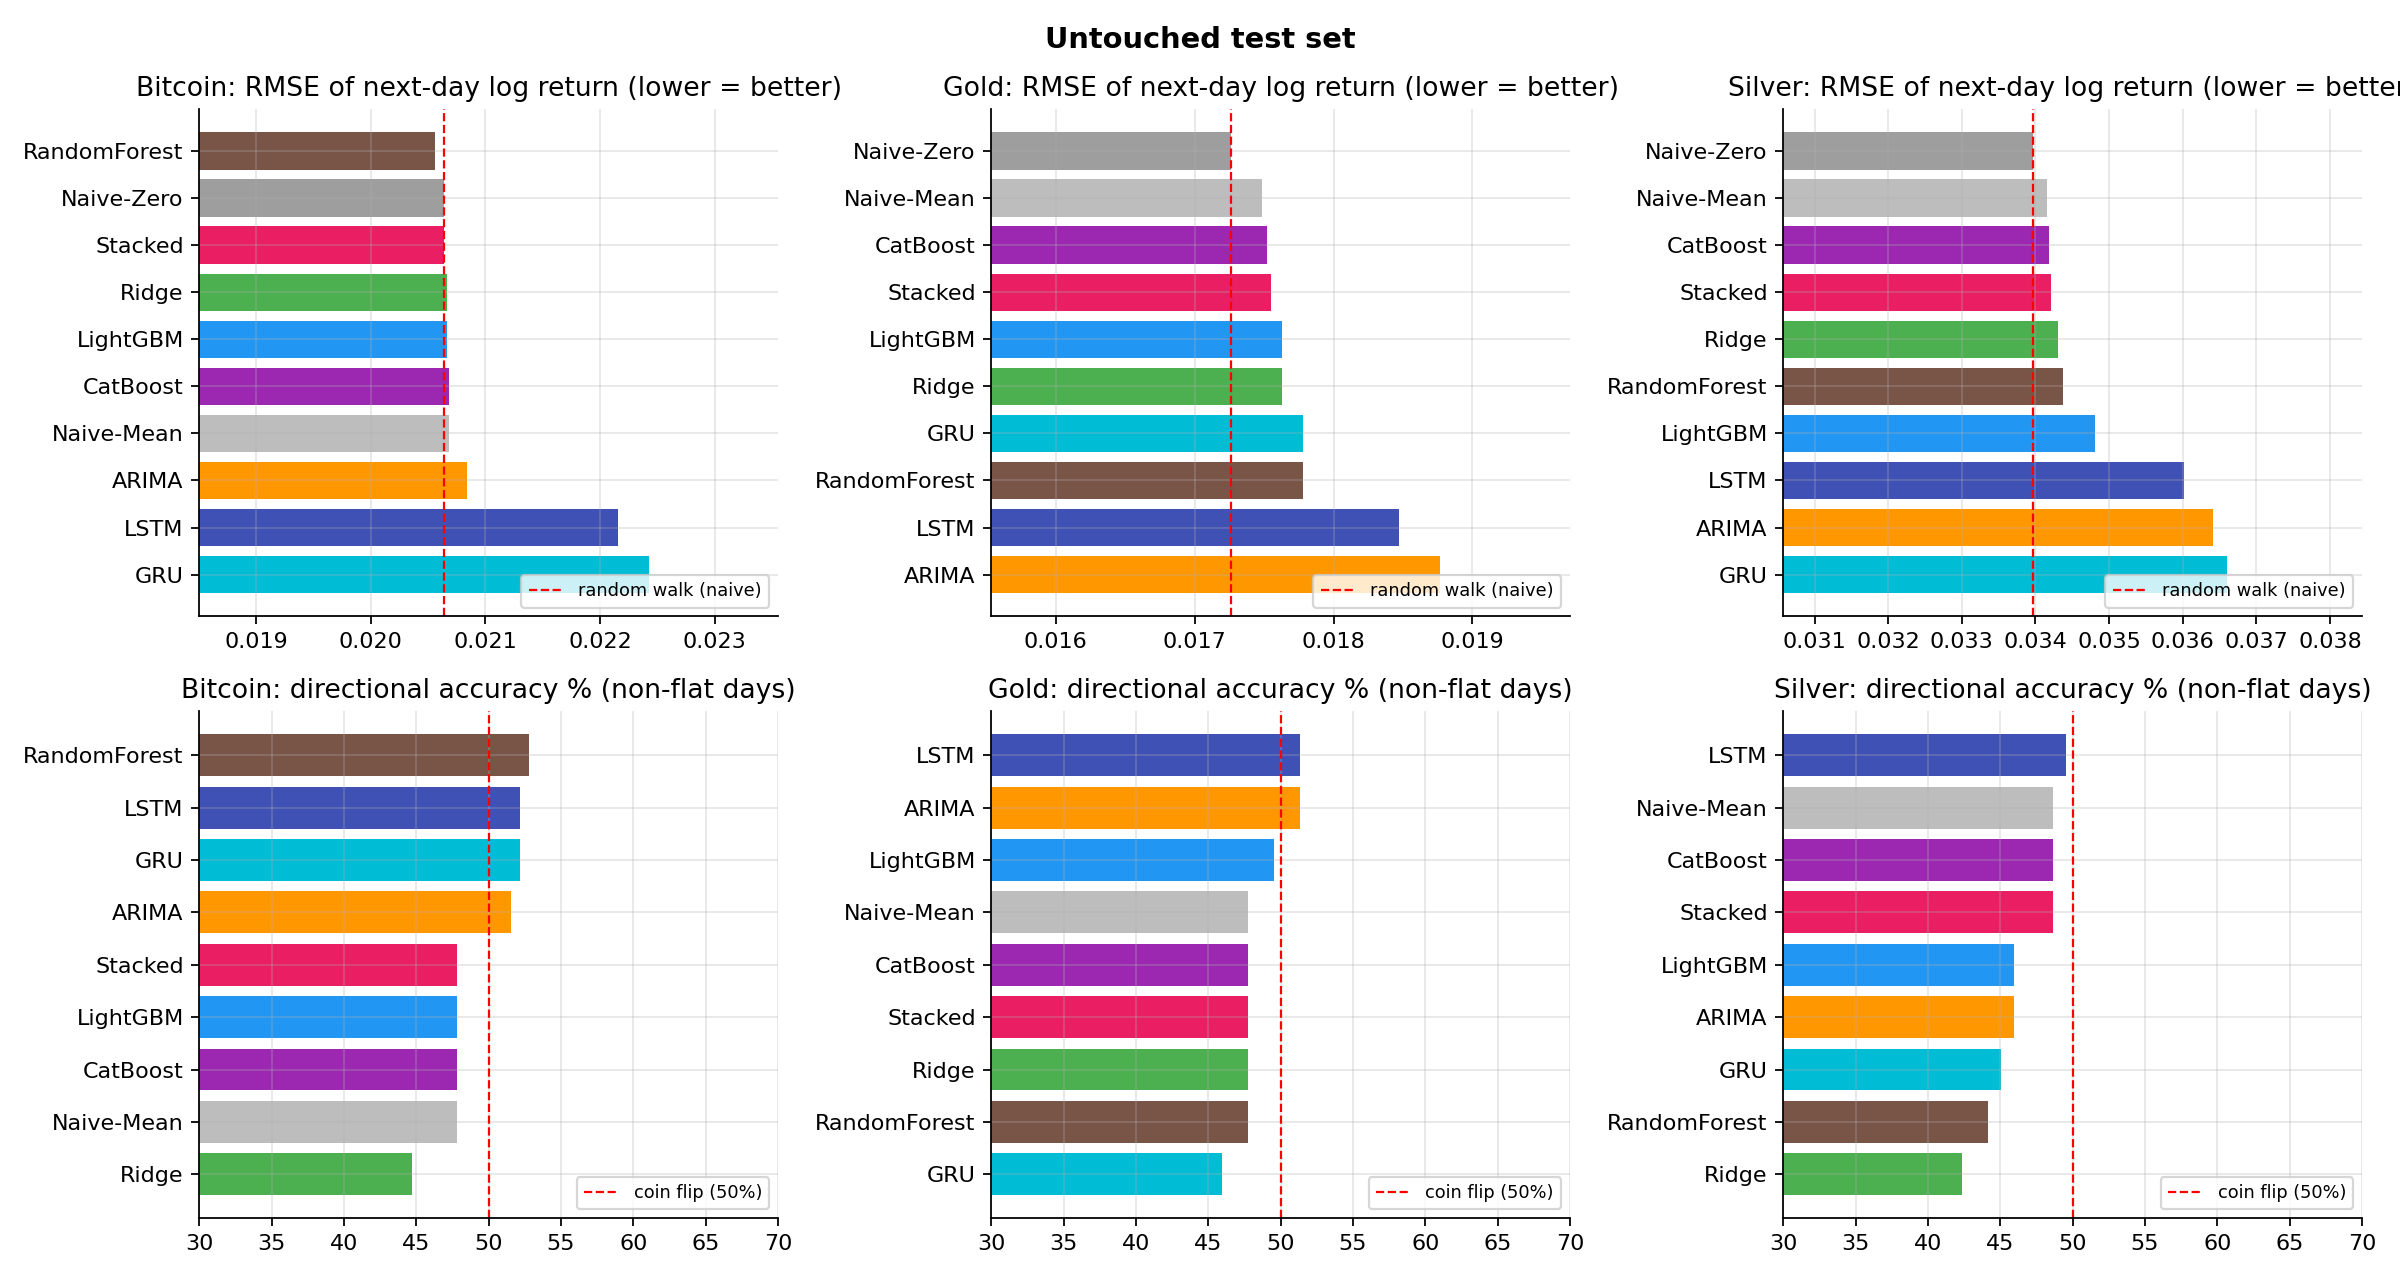

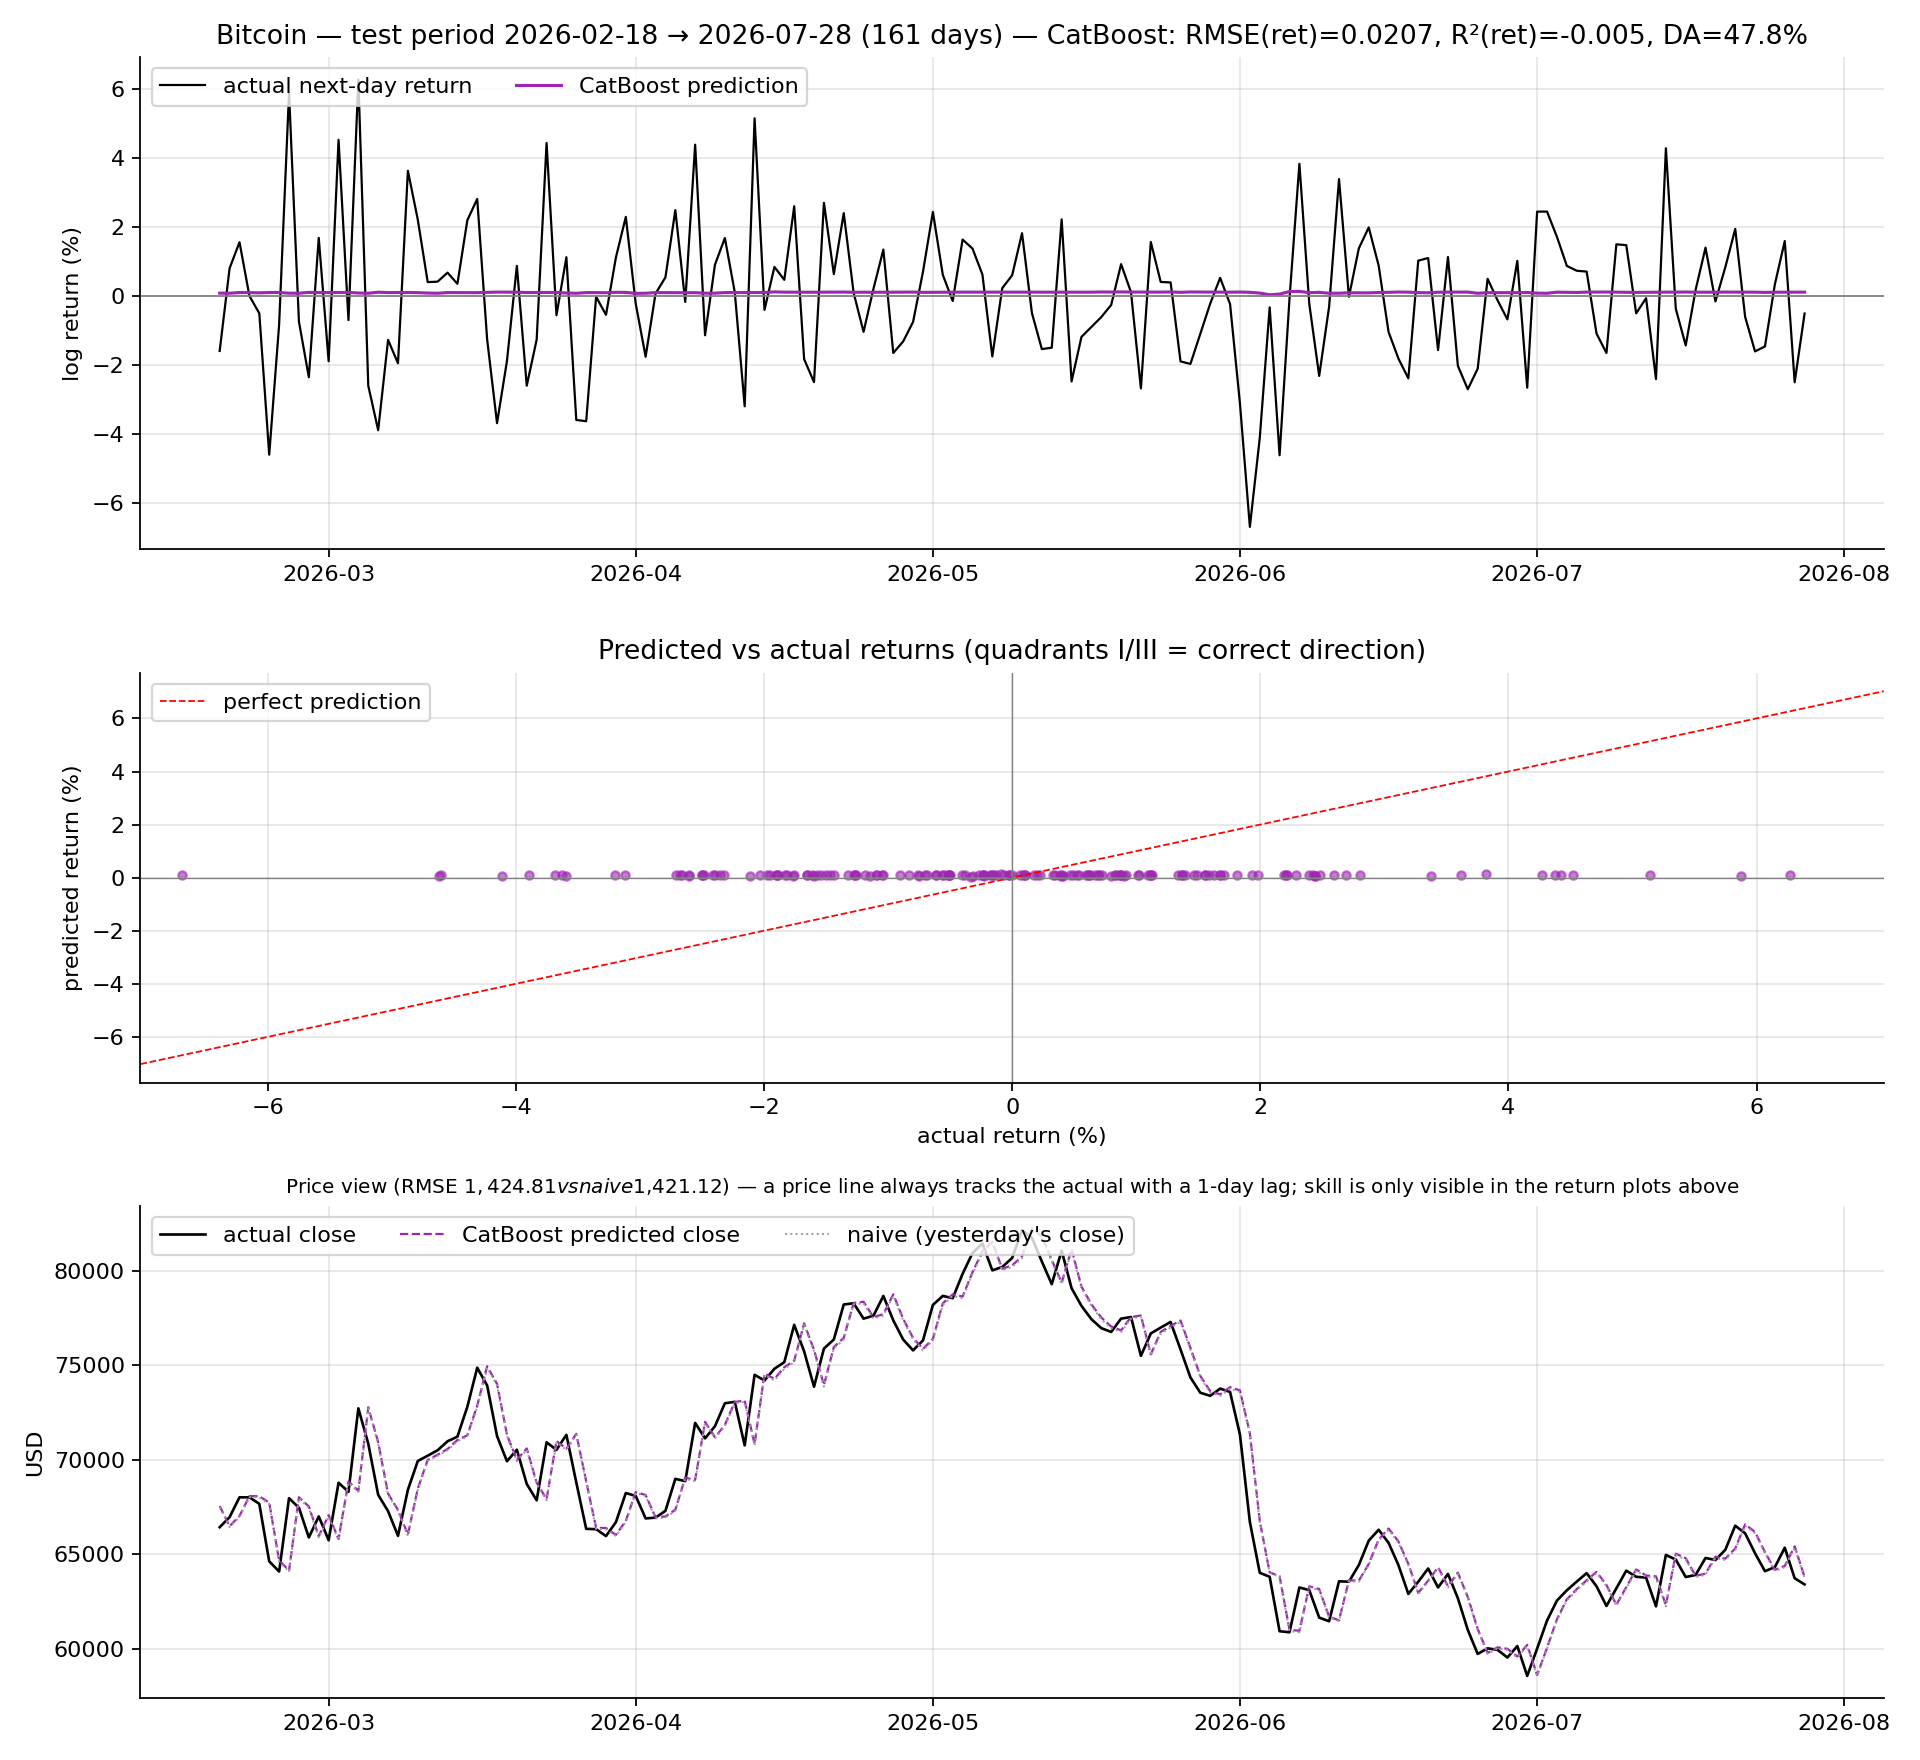

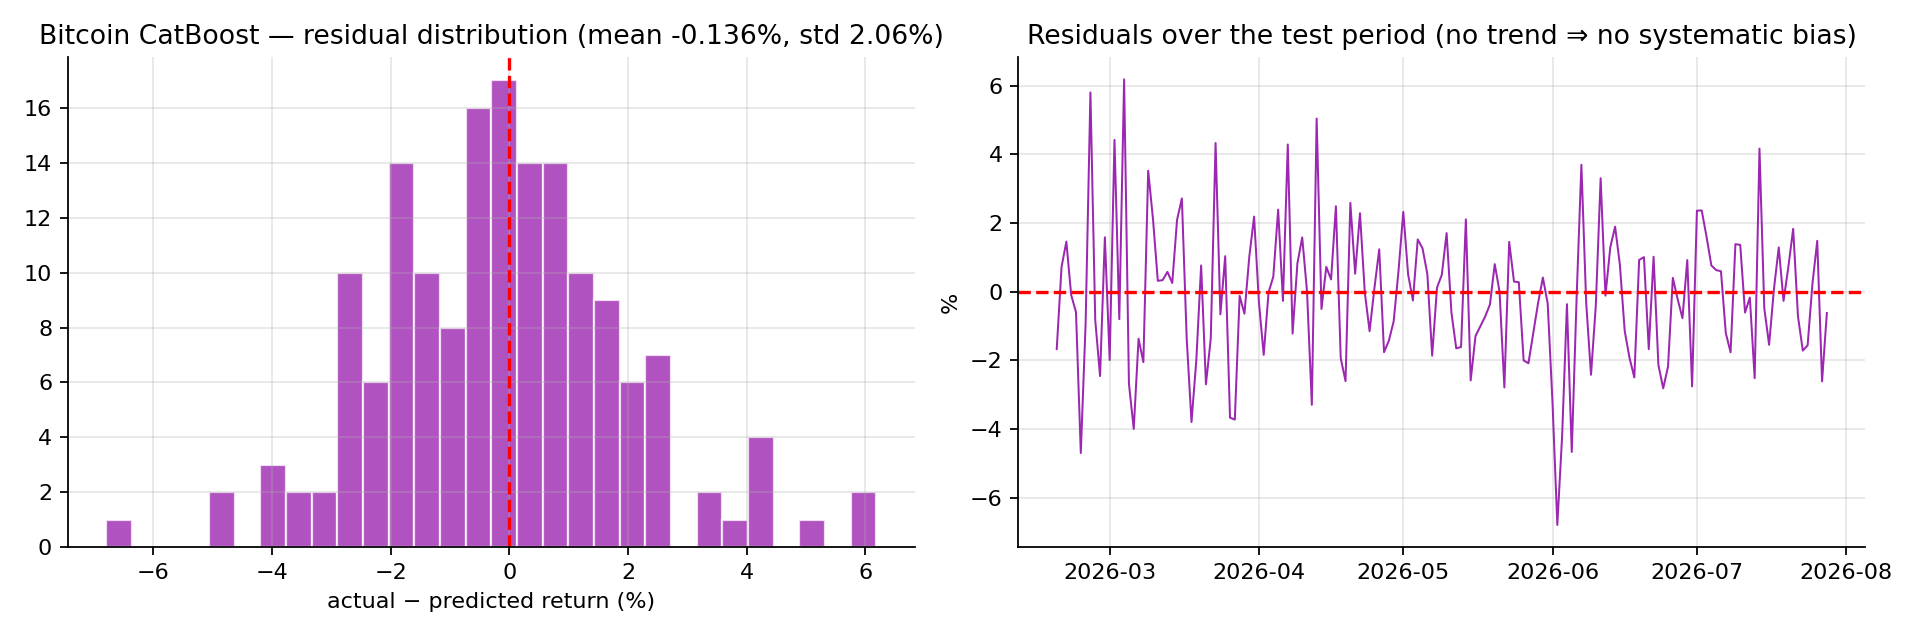

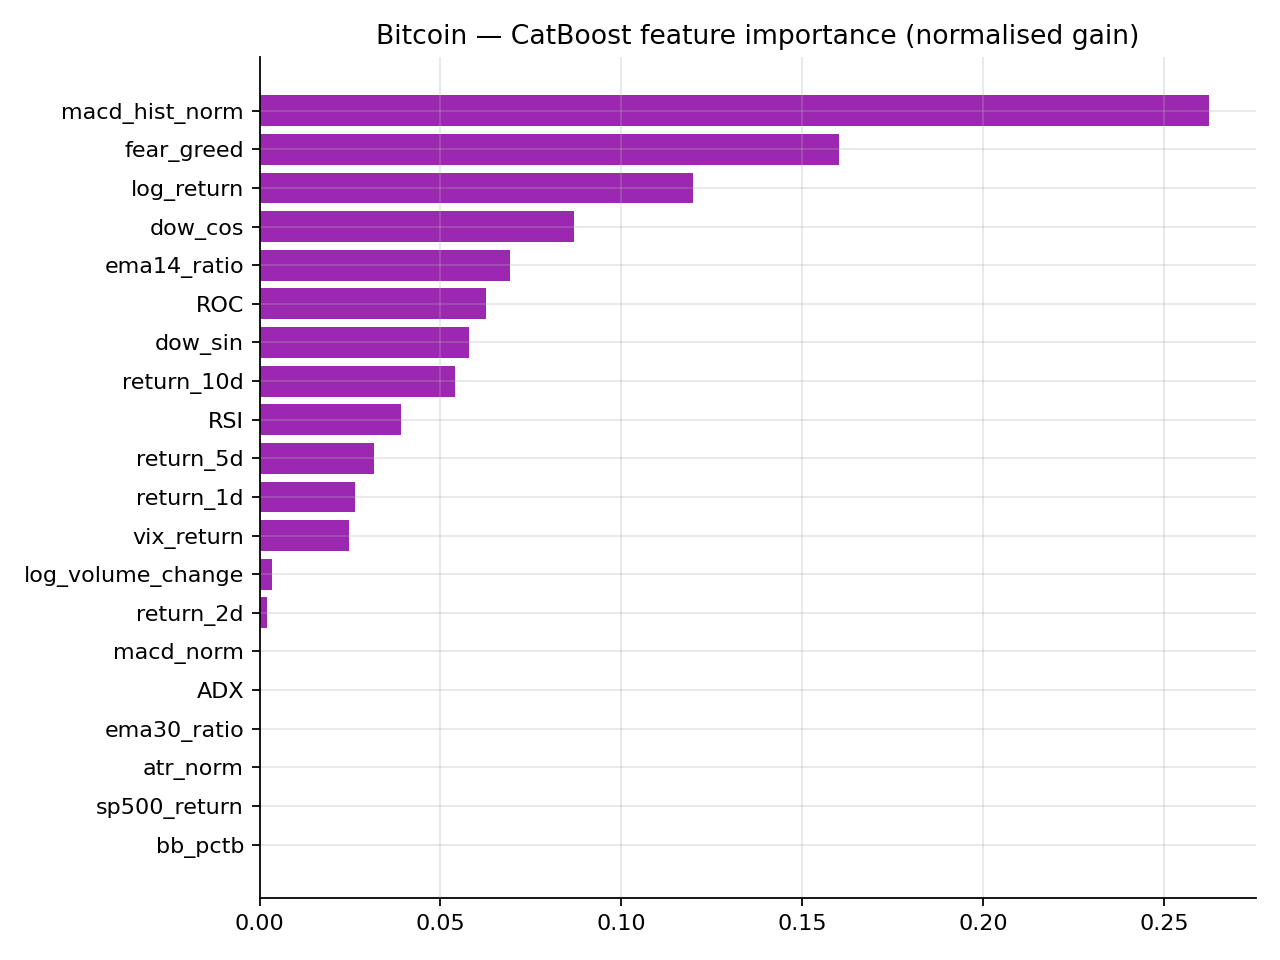

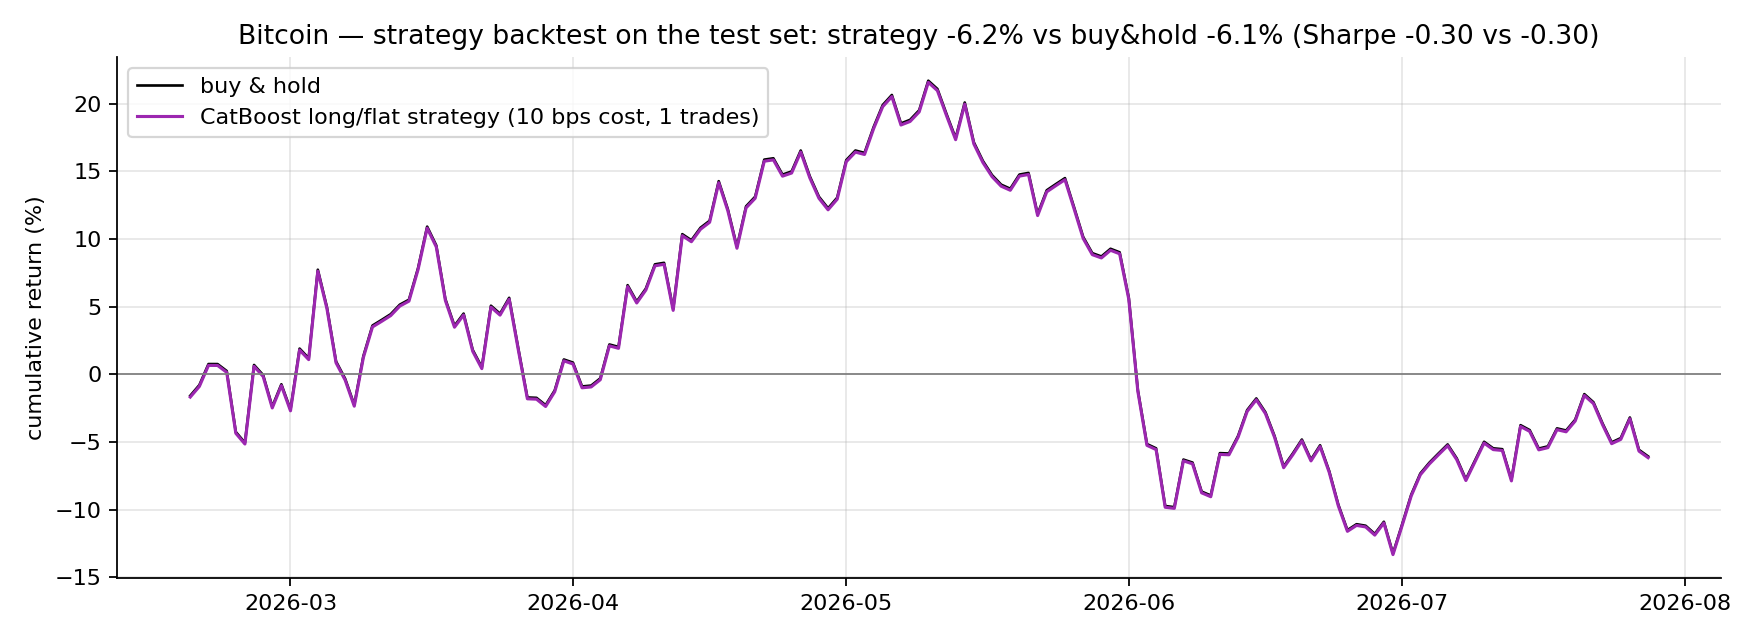

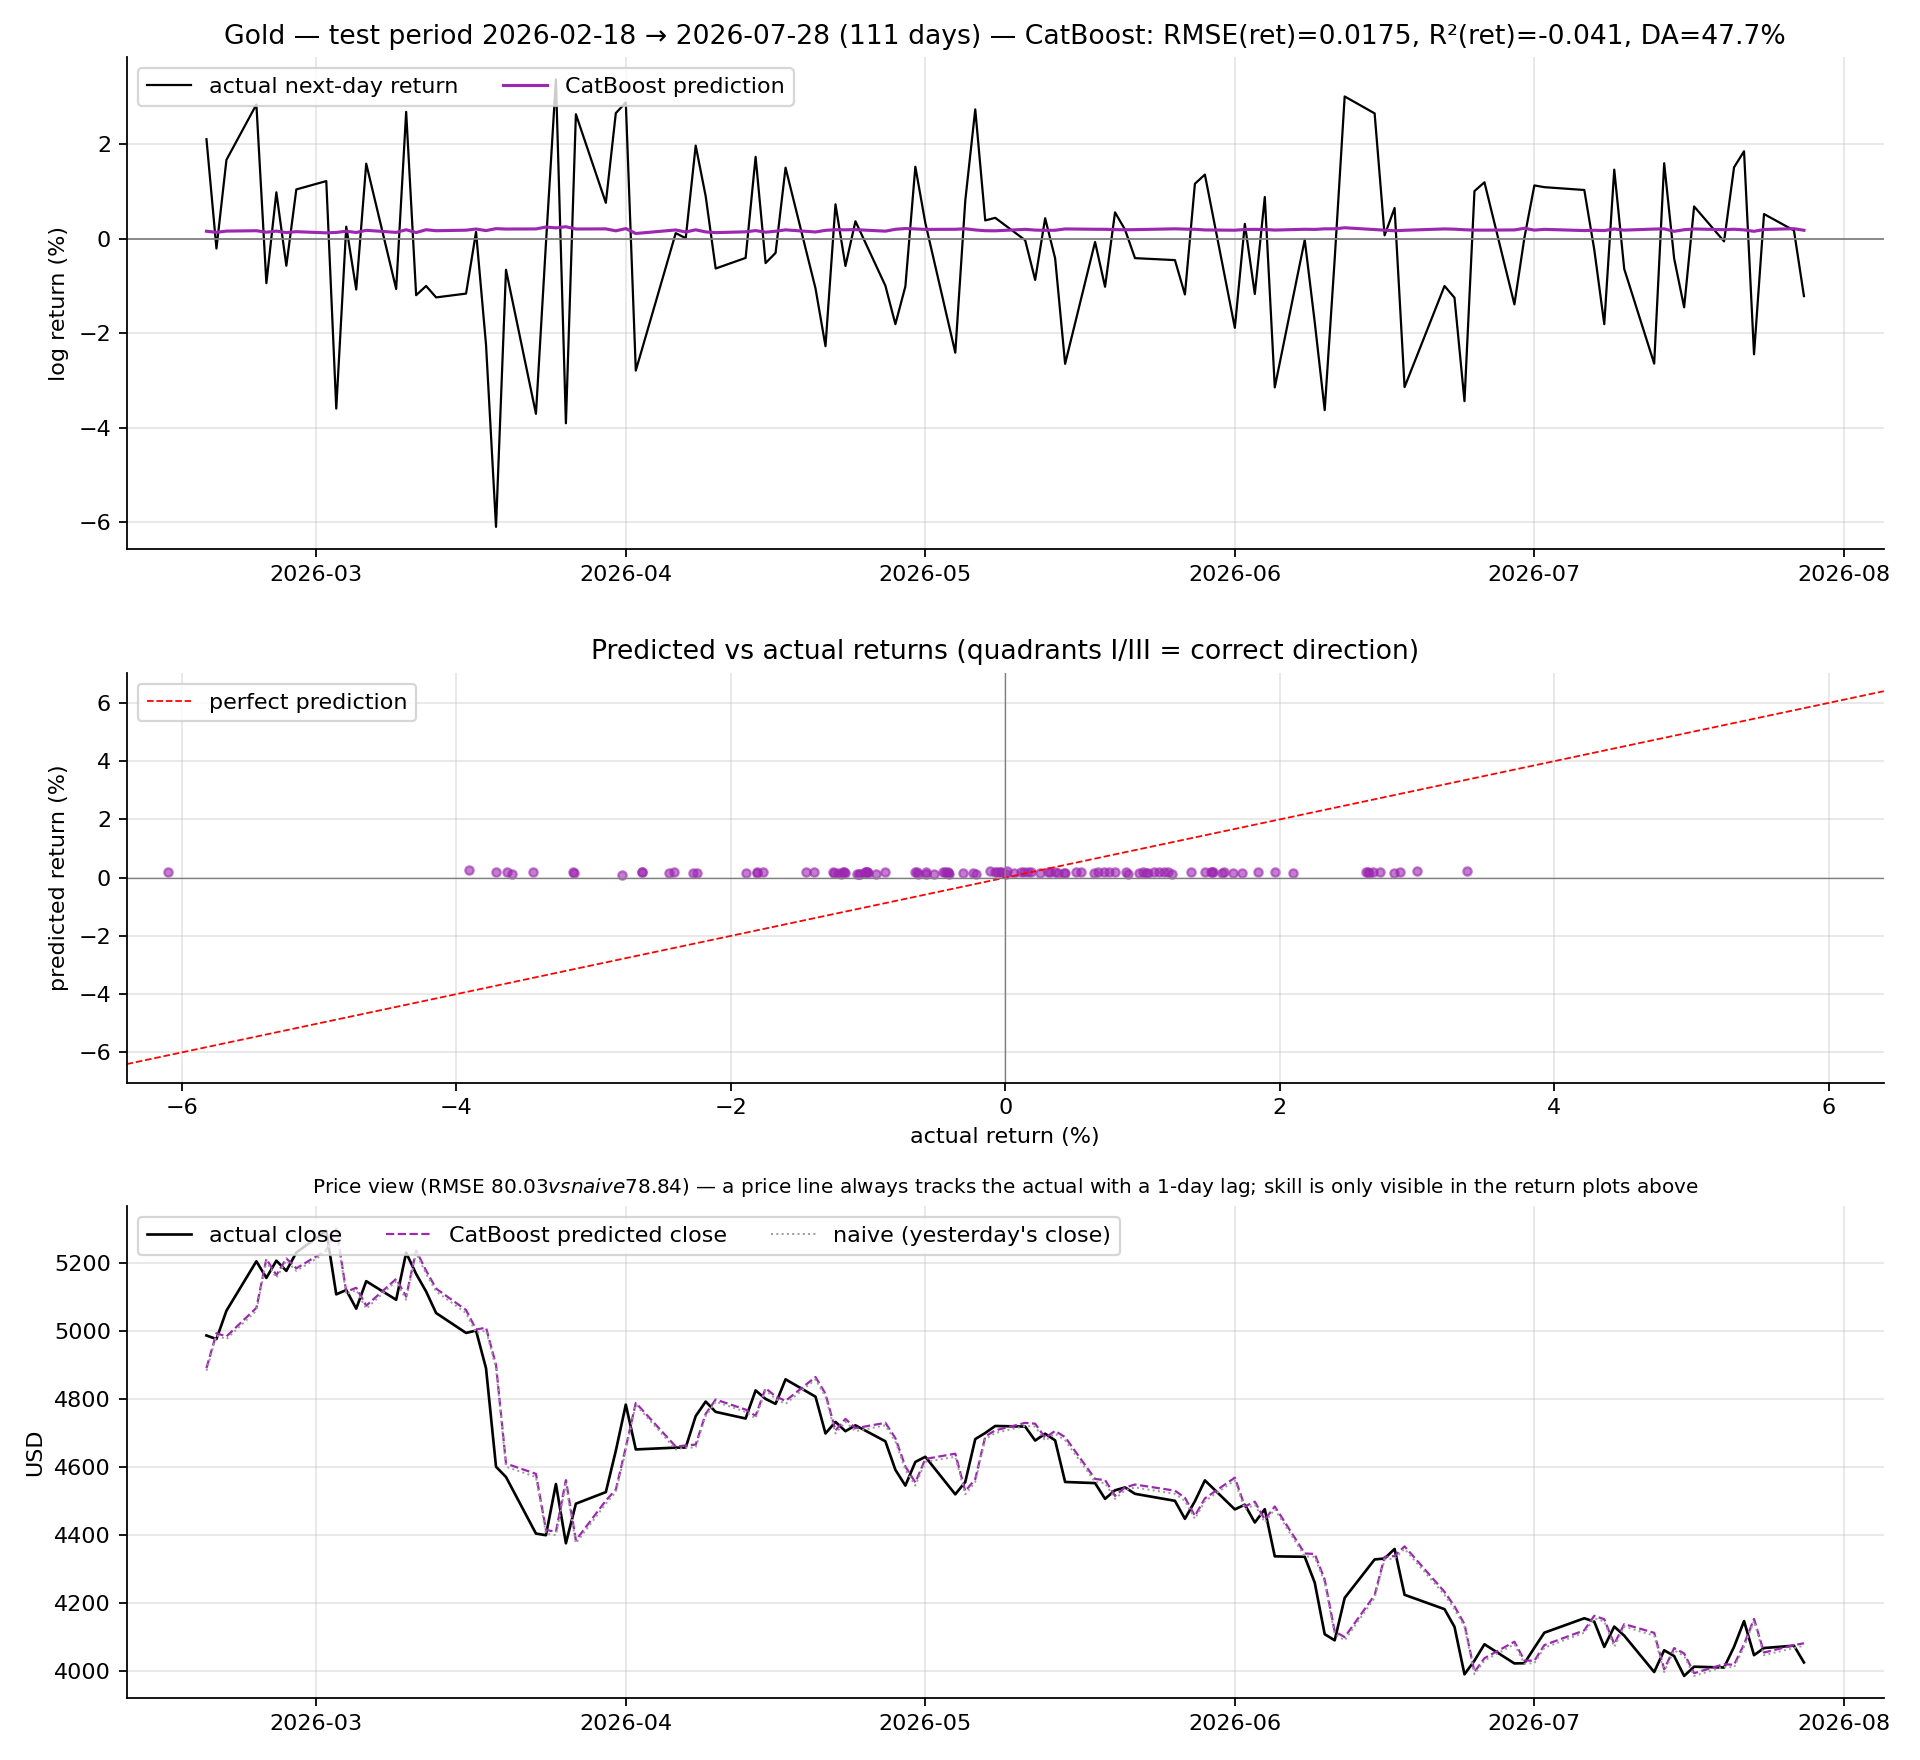

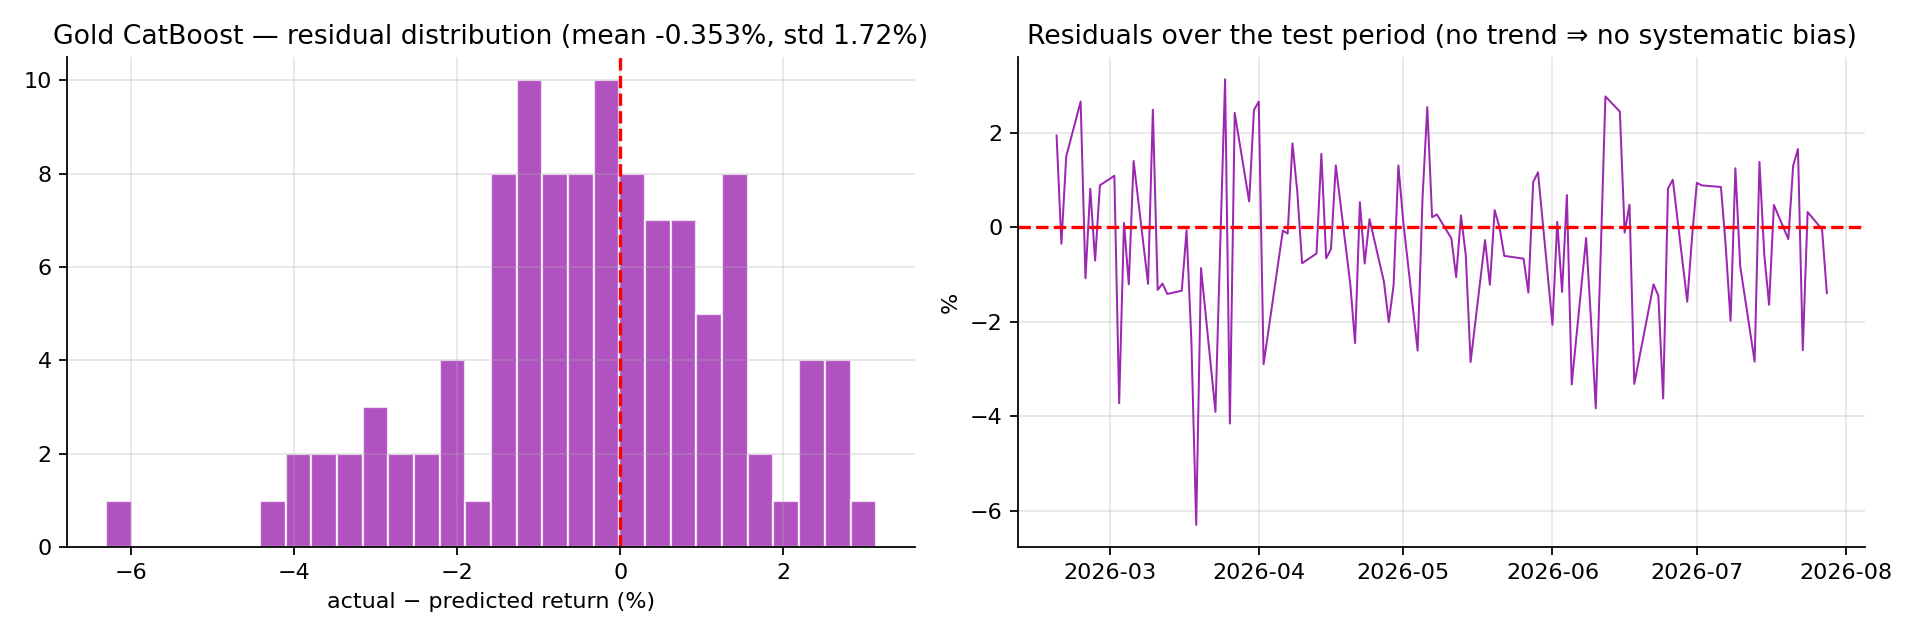

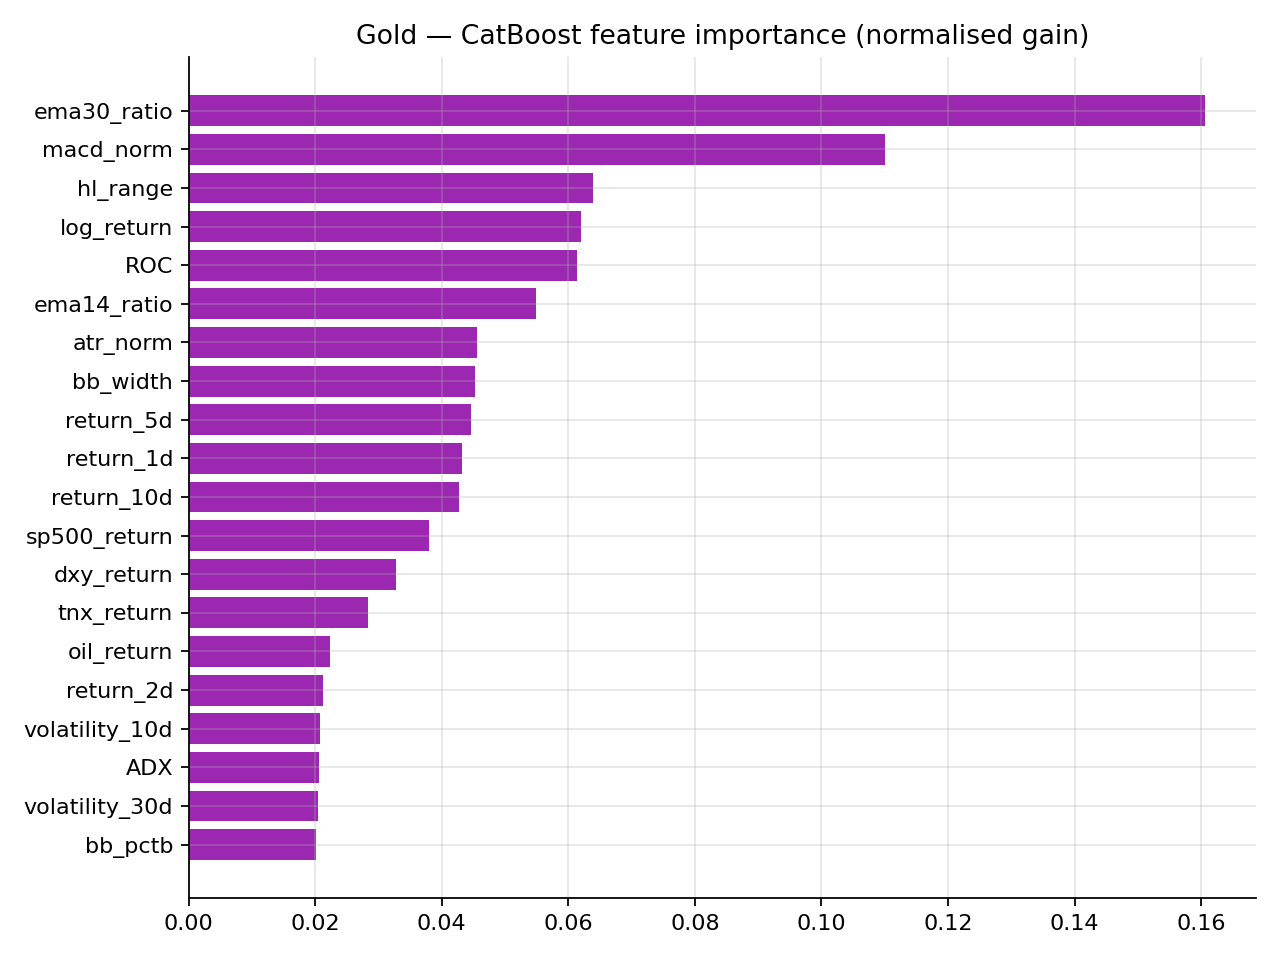

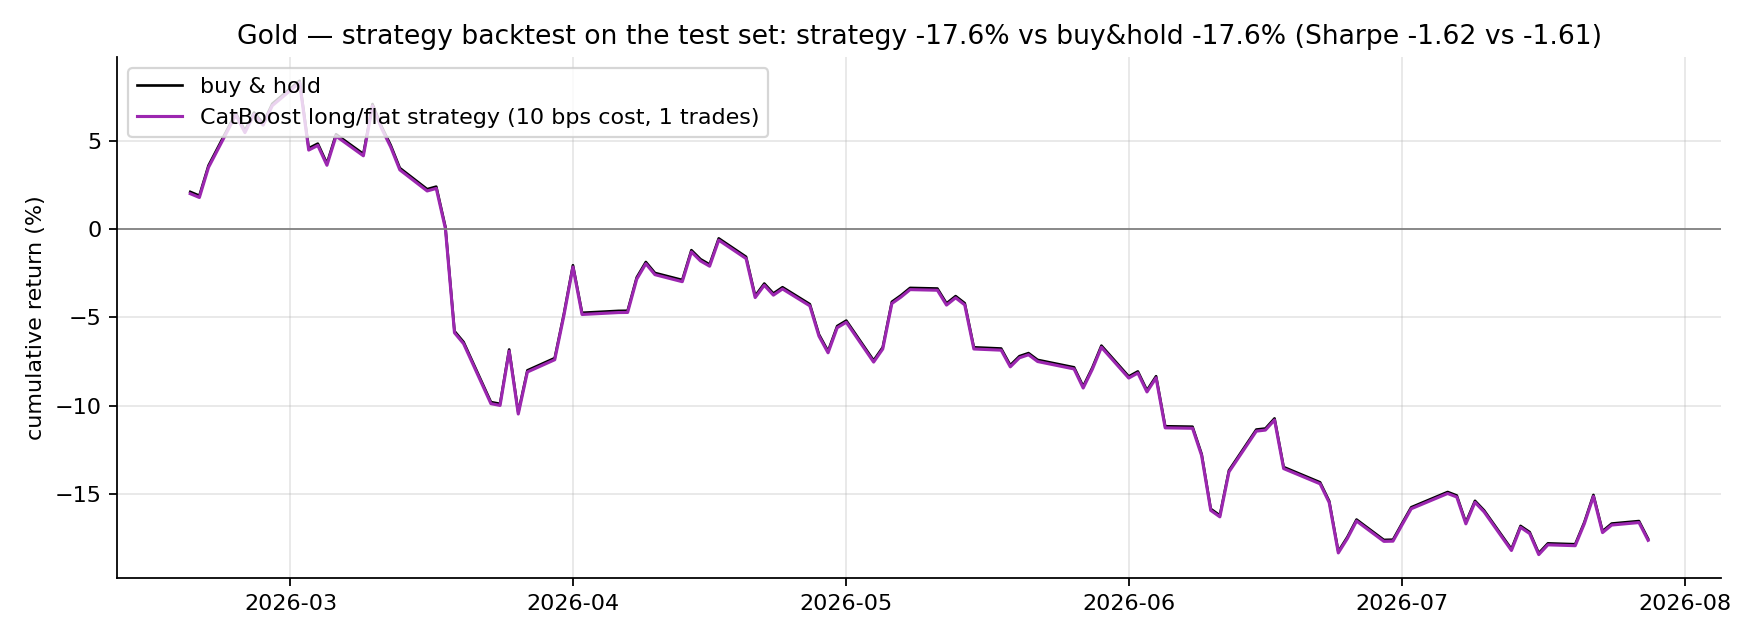

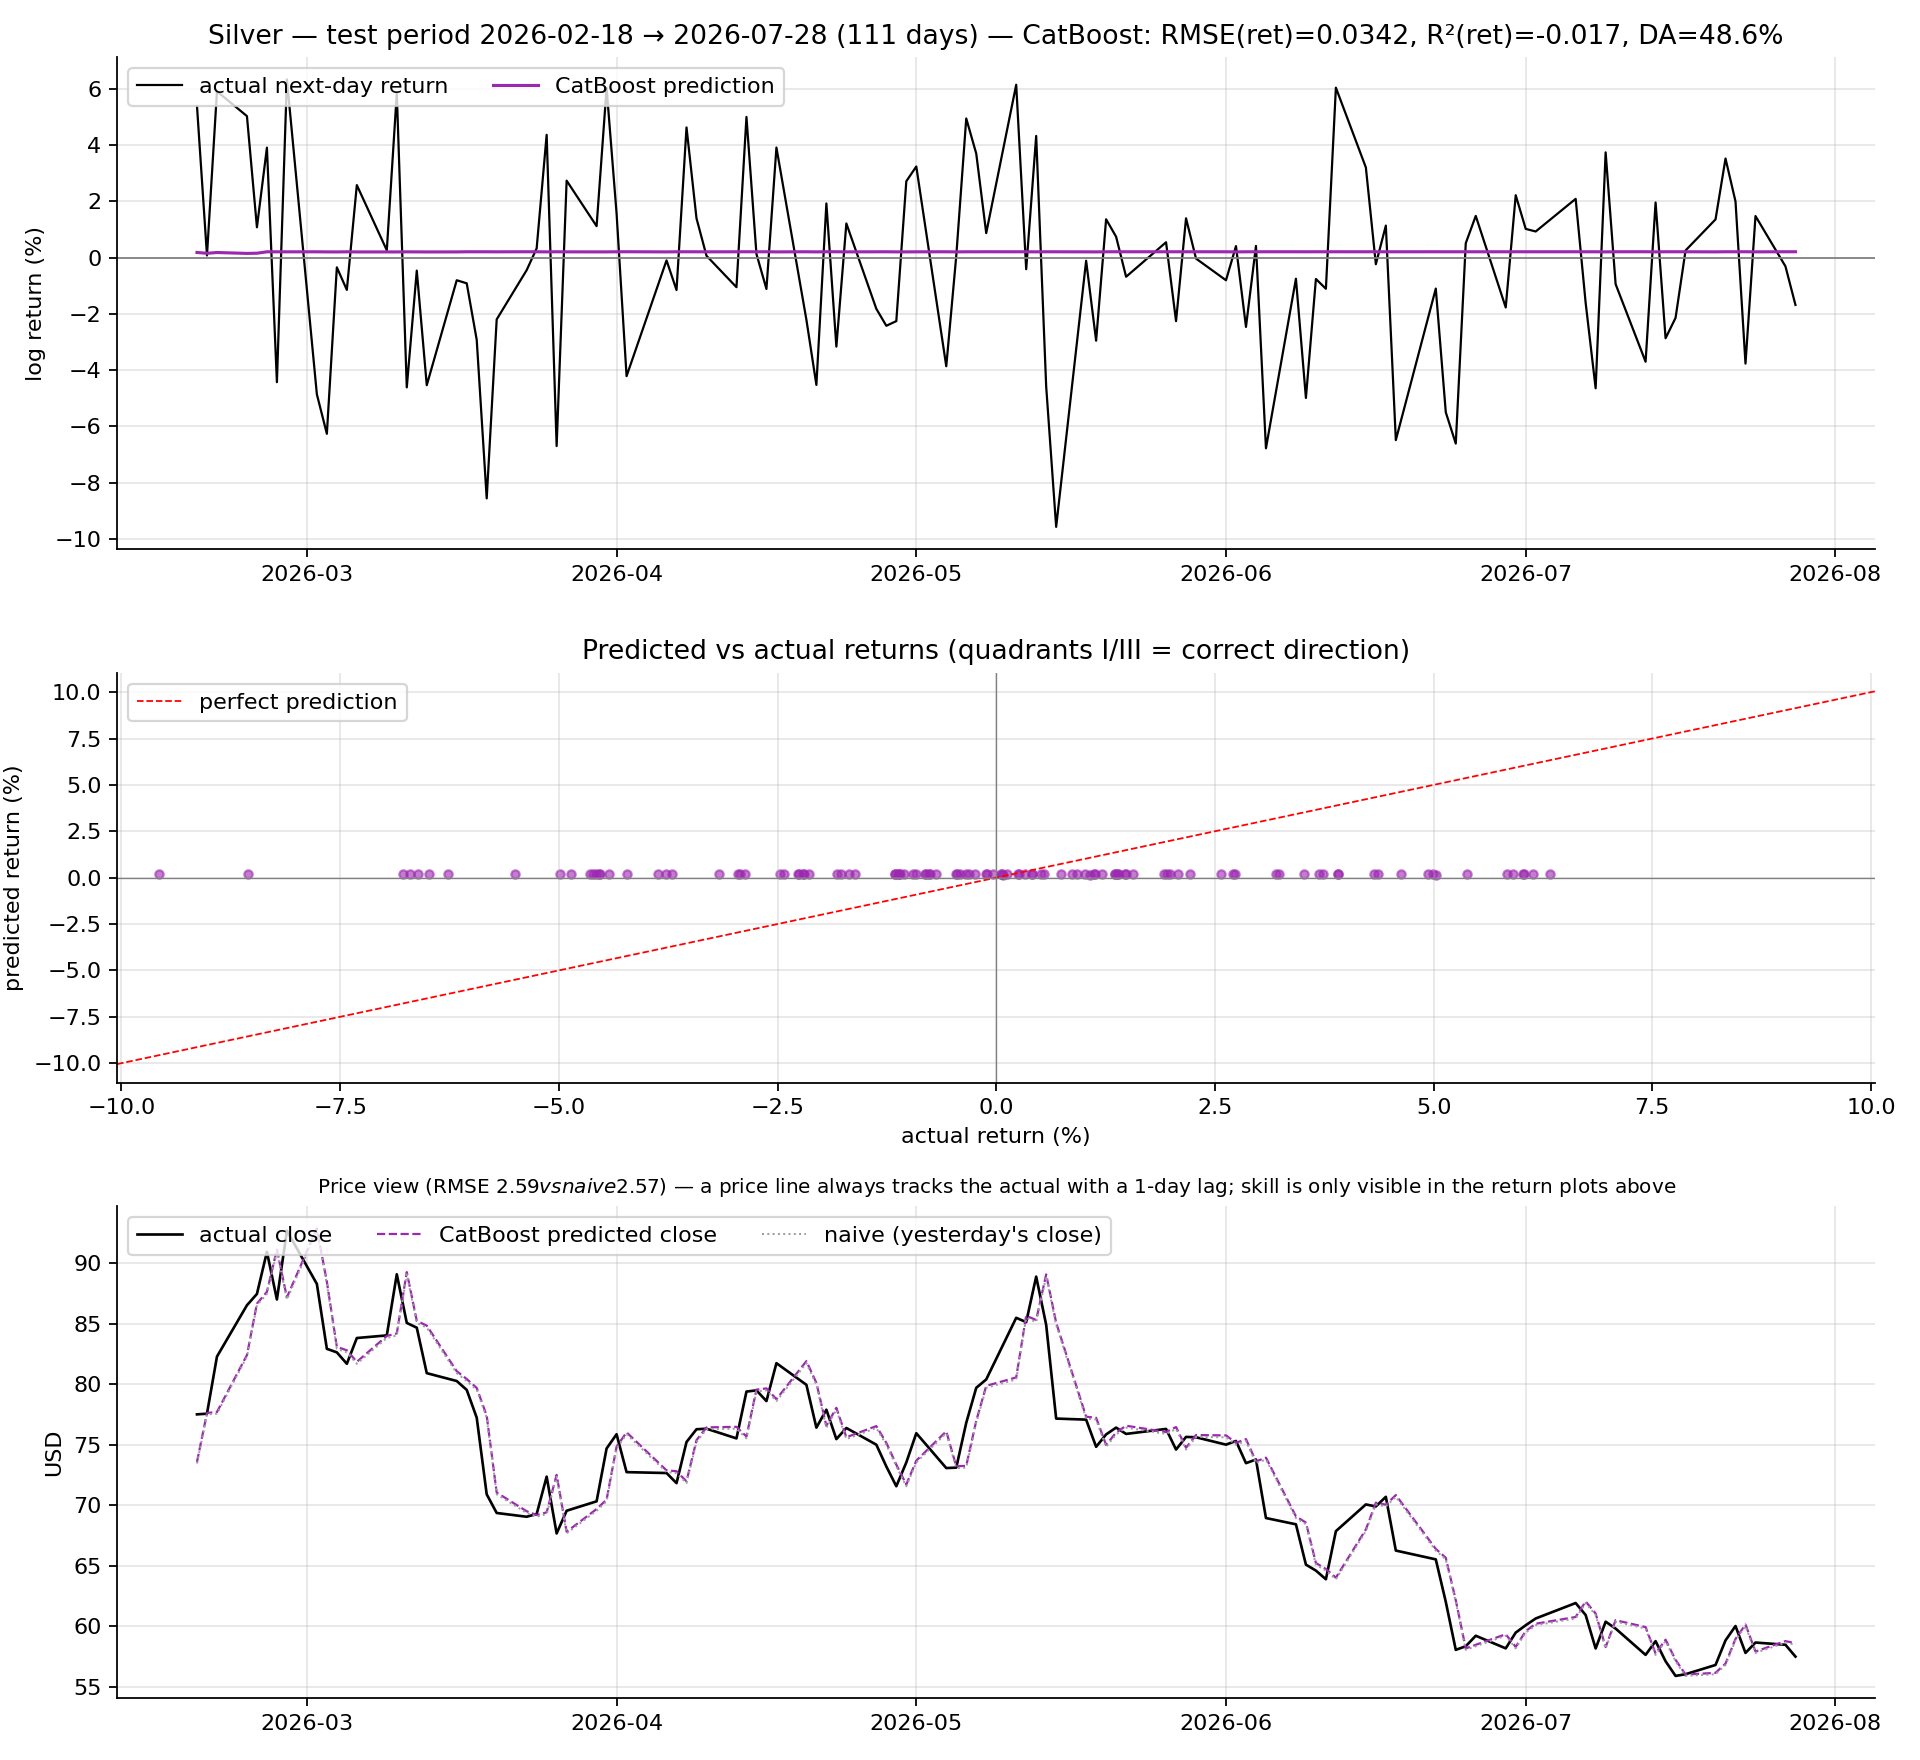

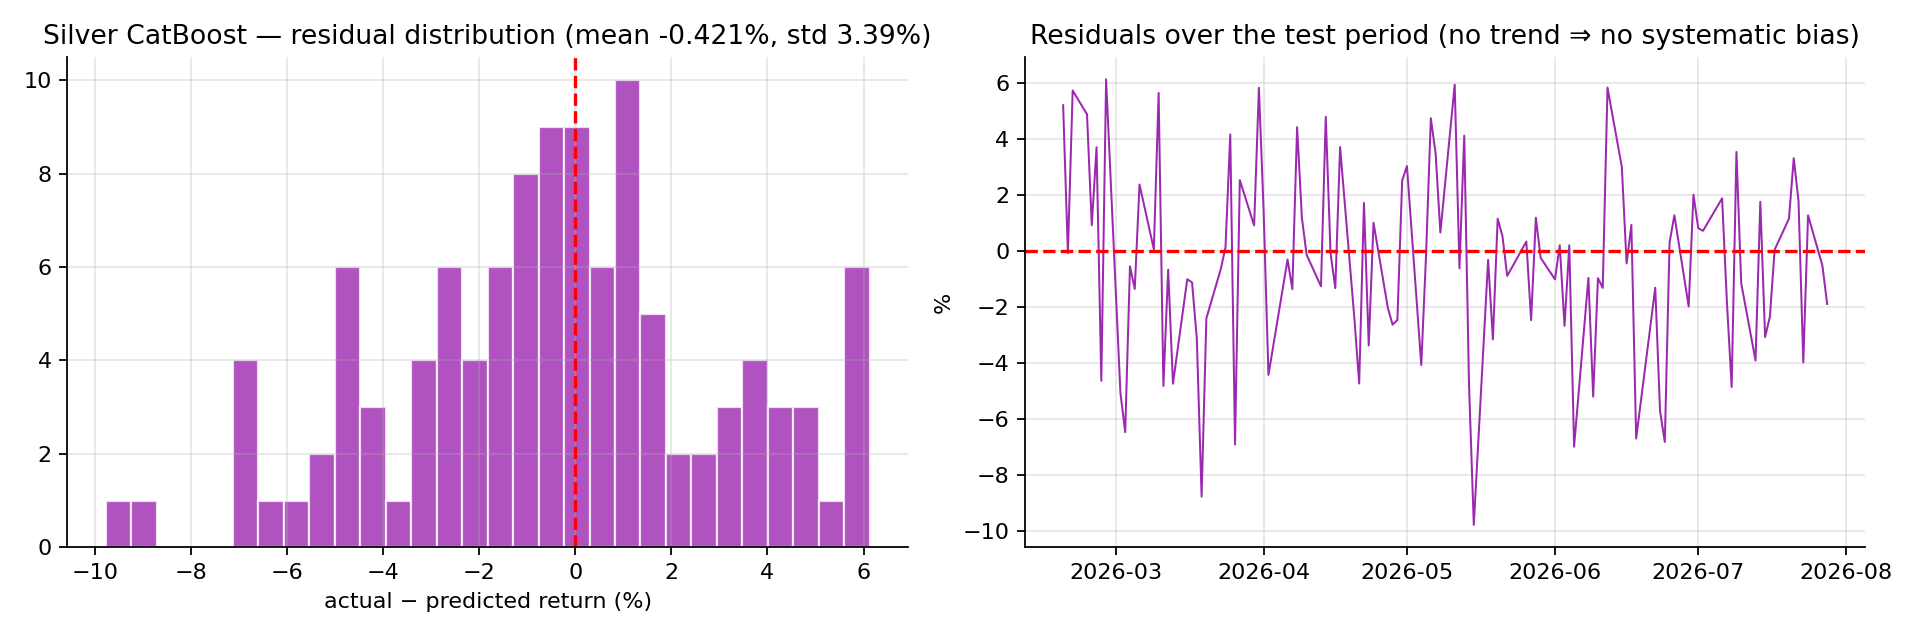

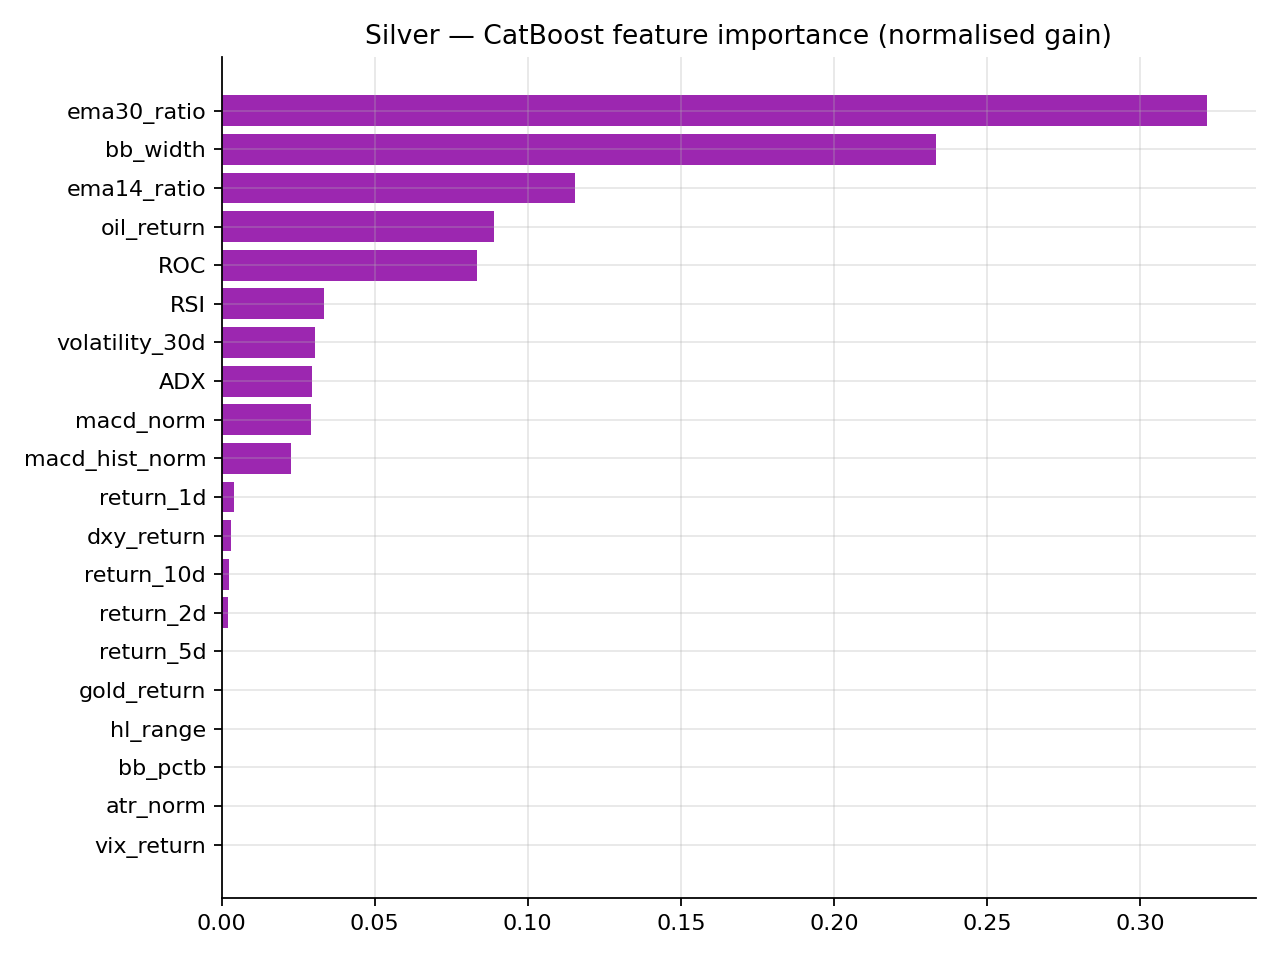

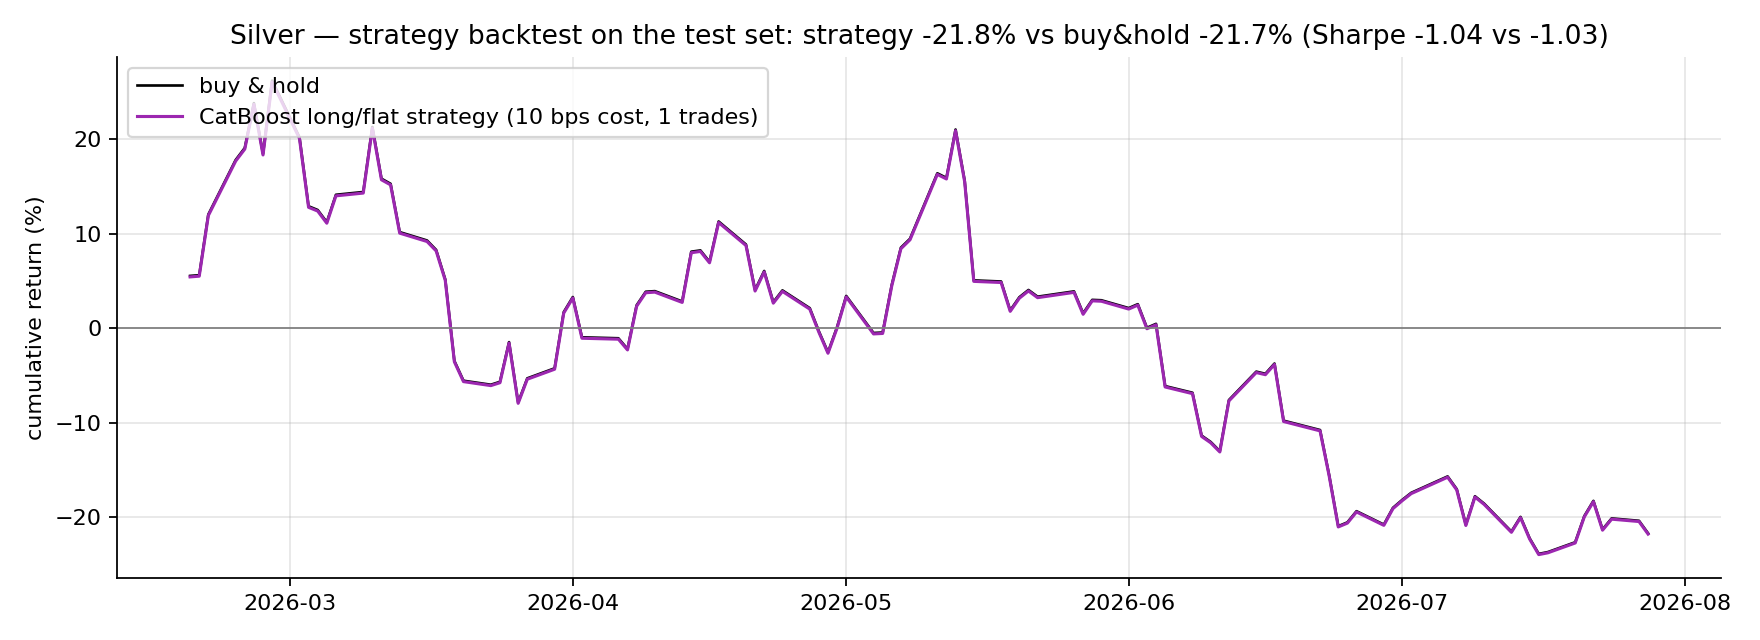

In [5]:
display(Image(os.path.join(FIGURES_DIR, 'model_comparison_test.png')))
for a in ASSETS:
    for s in ['actual_vs_predicted','residuals','feature_importance','strategy']:
        p = os.path.join(FIGURES_DIR, f'{get_prefix(a)}_{s}.png')
        if os.path.exists(p): display(Image(p))

## 3. Served model per asset

In [6]:
import json; s = json.load(open(MODEL_STATUS_PATH))
for a, v in s.items(): print(a, '→', v['primary_model'], '| CV RMSE', round(v['cv_rmse_ret'],5), 'vs naive', round(v['cv_rmse_ret_naive'],5))

Bitcoin → CatBoost | CV RMSE 0.02521 vs naive 0.02504
Gold → CatBoost | CV RMSE 0.01312 vs naive 0.01326
Silver → CatBoost | CV RMSE 0.02797 vs naive 0.02805


## 4. Conclusions
See `results/FINAL_RESULTS.md` and `docs/RESULTS.md` for the written interpretation.